In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Read the ARFF file manually (it was saved as df.md but the content is ARFF format)
with open('../data/raw/Rice_Cammeo_Osmancik.arff', 'r') as f:
    lines = f.readlines()

# Column names, in the order they appear in @ATTRIBUTE lines
columns = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
           'Eccentricity', 'Convex_Area', 'Extent', 'Class']

# Find where the actual data starts (after the @DATA line)
data_start = next(i for i, l in enumerate(lines) if l.strip().upper() == '@DATA') + 1
data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

# Parse into a DataFrame
rows = [l.split(',') for l in data_lines]
df = pd.DataFrame(rows, columns=columns)

# Convert numeric columns from text to actual numbers
num_cols = columns[:-1]
df[num_cols] = df[num_cols].astype(float)

# Save a clean CSV for every other notebook to reuse
df.to_csv('../data/raw/rice.csv', index=False)

print(df.shape)
df.head()

(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [12]:
print(df)

         Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0     15231.0  525.578979         229.749878          85.093788      0.928882   
1     14656.0  494.311005         206.020065          91.730972      0.895405   
2     14634.0  501.122009         214.106781          87.768288      0.912118   
3     13176.0  458.342987         193.337387          87.448395      0.891861   
4     14688.0  507.166992         211.743378          89.312454      0.906691   
...       ...         ...                ...                ...           ...   
3805  11441.0  415.858002         170.486771          85.756592      0.864280   
3806  11625.0  421.390015         167.714798          89.462570      0.845850   
3807  12437.0  442.498993         183.572922          86.801979      0.881144   
3808   9882.0  392.296997         161.193985          78.210480      0.874406   
3809  11434.0  404.709991         161.079269          90.868195      0.825692   

      Convex_Area    Extent

In [3]:
print(df.shape) 

(3810, 8)


In [4]:
#Check_missing_vlue
df.isnull().sum()

Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Eccentricity         0
Convex_Area          0
Extent               0
Class                0
dtype: int64

In [5]:
#Simulate_missing_values_(MCAR)_to_demonstrate_the_technique
np.random.seed(42)
df_missing = df.copy()

for col in ['Minor_Axis_Length', 'Eccentricity']:
    missing_idx = df_missing.sample(frac=0.05, random_state=42).index
    df_missing.loc[missing_idx, col] = np.nan

print("Missing values introduced:")
print(df_missing.isnull().sum())



Missing values introduced:
Area                   0
Perimeter              0
Major_Axis_Length      0
Minor_Axis_Length    190
Eccentricity         190
Convex_Area            0
Extent                 0
Class                  0
dtype: int64


In [6]:
#Impute_missing_values_using_median_(per-column)
df_imputed = df_missing.copy()

for col in ['Minor_Axis_Length', 'Eccentricity']:
    median_val = df_imputed[col].median()
    df_imputed[col] = df_imputed[col].fillna(median_val)
    print(f"{col}: filled with median = {median_val:.4f}")

print("\nRemaining missing values:")
print(df_imputed.isnull().sum())

Minor_Axis_Length: filled with median = 86.4246
Eccentricity: filled with median = 0.8890

Remaining missing values:
Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Eccentricity         0
Convex_Area          0
Extent               0
Class                0
dtype: int64


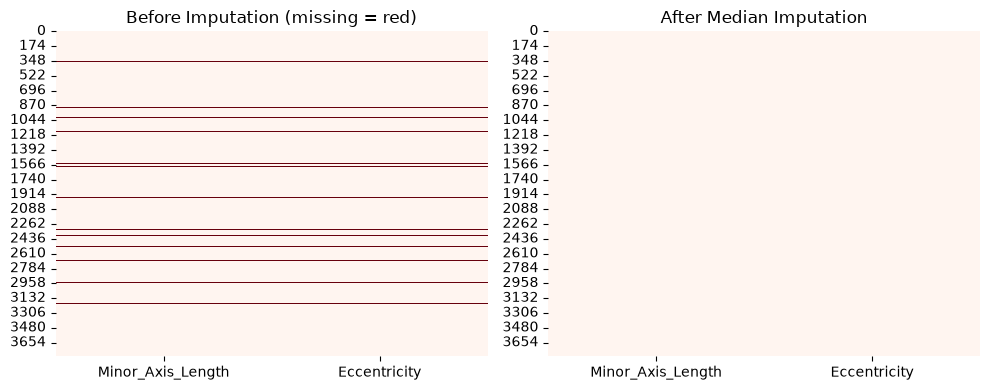

In [9]:
#EDA_Visualization - Missingness_after_vs_before
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(df_missing[['Minor_Axis_Length', 'Eccentricity']].isnull(),
            cbar=False, cmap='Reds', ax=axes[0])
axes[0].set_title('Before Imputation (missing = red)')
sns.heatmap(df_imputed[['Minor_Axis_Length', 'Eccentricity']].isnull(),
            cbar=False, cmap='Reds', ax=axes[1])
axes[1].set_title('After Median Imputation')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member1_missingness_heatmap.png', dpi=150)
plt.show()
